In [1]:
from Charts.ploTools import *
from Charts.resumeTools import *
import pickle

In [2]:
from glob import glob

In [3]:
# PREFIX_EXP = "OptimizeIterationsResults/OptunaDDPGExpBase/00000*/*" # Base
PREFIX_EXP = "OptimizeIterationsResults/OptunaDDPGExpBase_Total/00000*/*" # 

glob(f"{PREFIX_EXP}/*.pkl")

['OptimizeIterationsResults/OptunaDDPGExpBase_Total\\000000\\2024-10-26_00-46-07_218\\metadata.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_Total\\000000\\2024-10-26_00-46-07_218\\metrics_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_Total\\000000\\2024-10-26_00-46-07_218\\metrics_resume_testing.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_Total\\000000\\2024-10-26_00-46-07_218\\training_rewards_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_Total\\000001\\2024-10-26_01-05-40_860\\metadata.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_Total\\000001\\2024-10-26_01-05-40_860\\metrics_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_Total\\000001\\2024-10-26_01-05-40_860\\metrics_resume_testing.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_Total\\000001\\2024-10-26_01-05-40_860\\training_rewards_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_Total\\0000010\\2024-10-26_04-03-20_755\\metadata.pkl',
 'OptimizeIterations

In [4]:
PATH_DATA_LIST_METRICS_RESUME = glob(PREFIX_EXP + "/metrics_resume.pkl")
PATH_DATA_LIST_METRICS_RESUME_TESTING  = glob(PREFIX_EXP + "/metrics_resume_testing.pkl")
PATH_DATA_LIST_TRAINING_REWARDS_RESUME = glob(PREFIX_EXP + "/training_rewards_resume.pkl")
print("{Q_archivos} archivos encontrados".format(Q_archivos=len(PATH_DATA_LIST_METRICS_RESUME)))

100 archivos encontrados


In [5]:
#metrics_resume_avg = mean_data(PATH_DATA_LIST)
metrics_resume_avg = mean_resume_data(PATH_DATA_LIST_METRICS_RESUME)
metrics_resume_testing_avg = mean_resume_data(PATH_DATA_LIST_METRICS_RESUME_TESTING)
training_rewards_resume_avg = mean_training_reward_data(PATH_DATA_LIST_TRAINING_REWARDS_RESUME)

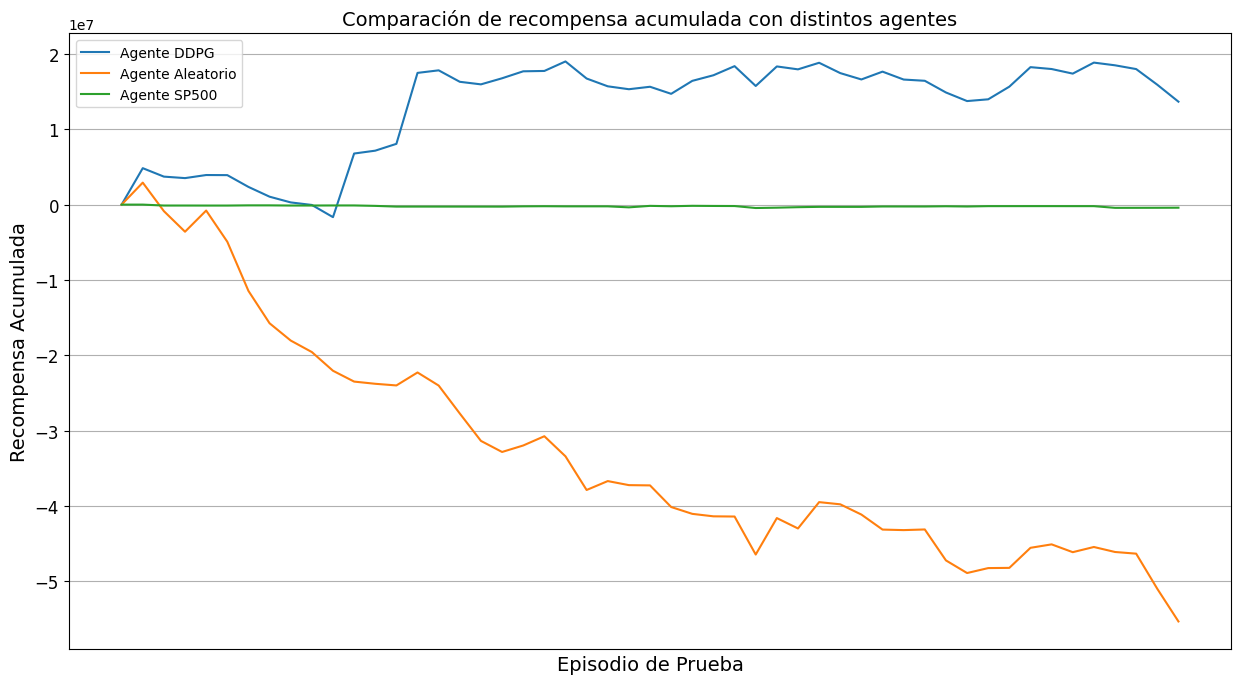

In [6]:
# Output 1 - Training Rewards
label_list_dict = {'DDPG Agent': 'Agente DDPG', 
                   'Random Agent': 'Agente Aleatorio',
                   'SP500 Agent': 'Agente SP500',
                   'title': 'Comparación de recompensa acumulada con distintos agentes',
                   'xlabel': 'Episodio de Prueba',
                   'ylabel': 'Recompensa Acumulada',}


plotCumulativeRewardMultiAgents(metrics_resume_avg , label_list_dict=label_list_dict)

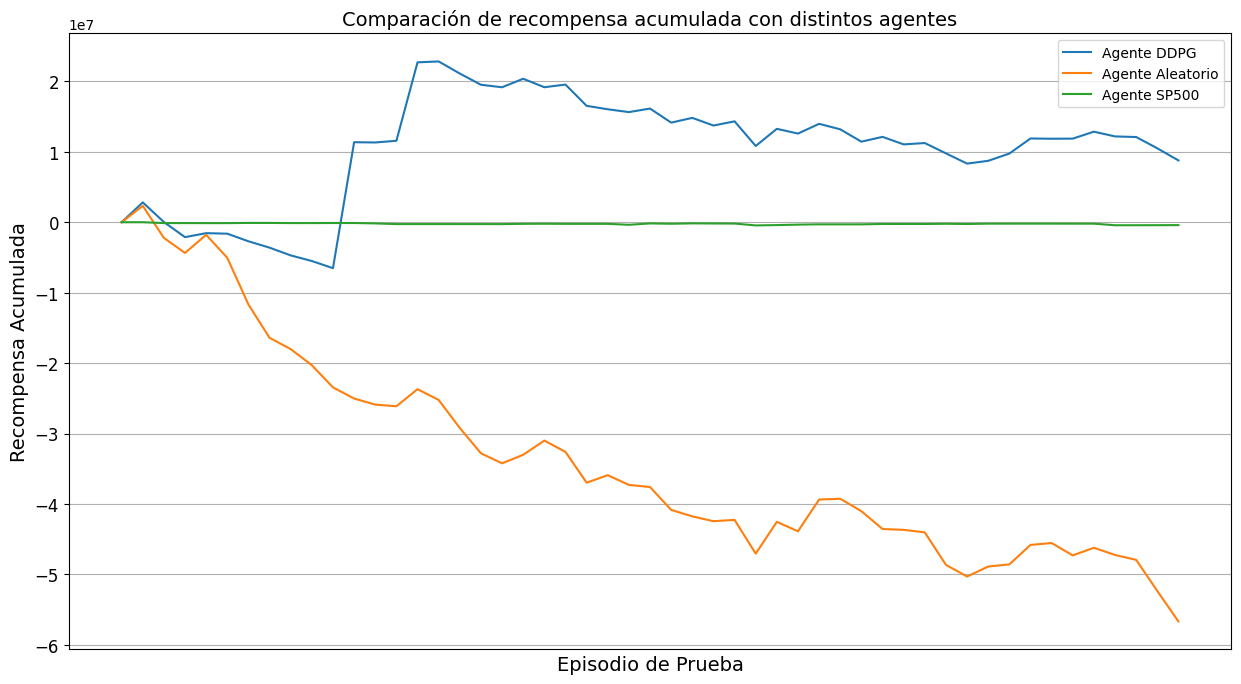

In [7]:
#G2
label_list_dict = {'DDPG Agent': 'Agente DDPG', 
                   'Random Agent': 'Agente Aleatorio',
                   'SP500 Agent': 'Agente SP500',
                   'title': 'Comparación de recompensa acumulada con distintos agentes',
                   'xlabel': 'Episodio de Prueba',
                   'ylabel': 'Recompensa Acumulada'}

# Output 2 - Training Rewards - last Agent
plotCumulativeRewardMultiAgents(metrics_resume_testing_avg, path_to_save= "G2_BaseModel_", label_list_dict=label_list_dict)

In [ ]:
# G3
label_list_dict = {'DDPG Agent': 'Agente DDPG', 
                   'Random Agent': 'Agente Aleatorio',
                   'SP500 Agent': 'Agente SP500',
                   'title': 'Comparación de patrimonio neto acumulado con distintos agentes',
                   'xlabel': 'Episodio de Prueba',
                   'ylabel': 'Patrimonio Neto Acumulado',}
# Output 3 - Cumulative Networth 
plotCumulativeNetWorthMultiAgents(metrics_resume_avg, path_to_save= "G3_BaseModel_", label_list_dict=label_list_dict)

KeyError: 'Agente DDPG'

<Figure size 1500x800 with 0 Axes>

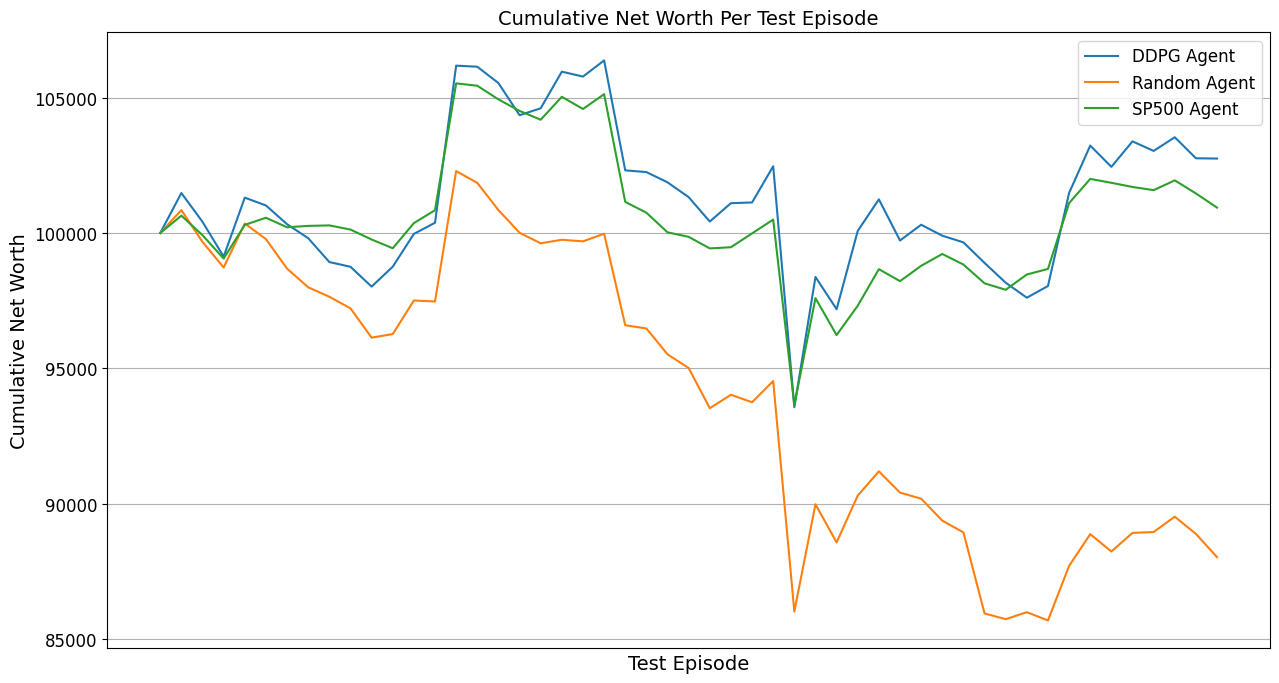

In [6]:
# Output 4 - Cumulative Networth - last Agent
result0 = plotCumulativeNetWorthMultiAgents(metrics_resume_testing_avg)

In [7]:
result0.keys()

dict_keys(['DDPG Agent', 'Random Agent', 'SP500 Agent'])

In [44]:
import pandas as pd
#pd.DataFrame.from_dict(result0['DDPG Agent'])
agentName = 'SP500 Agent'
df = pd.DataFrame(data=[['T 0'] + result0[agentName]['dates'] , result0[agentName]['patAcum']]).T
df.columns  = ['Time', 'patAcum']
df['Serie'] = agentName
df.to_csv(f'dataChartsForPaper/{agentName}patAcum.csv',index=False)

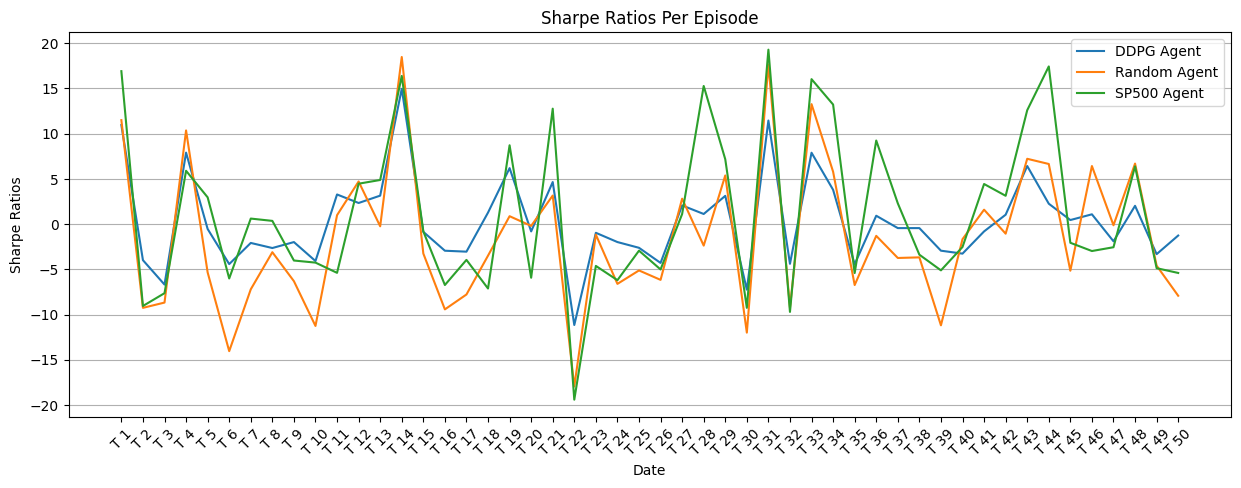

In [10]:
# Output 5 - Ratio Sharpe
plotSharpeRatioMultiAgents(metrics_resume_testing_avg)

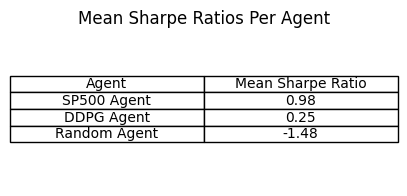

In [14]:
# Output 5 - Ratio Sharpe Table
# T1
plotTableMeanSharpeRatioMultiAgents(metrics_resume_testing_avg)

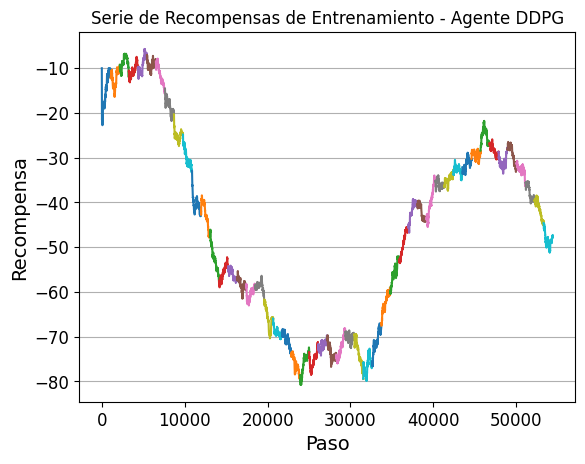

In [7]:
# G1
# Output 6 - Training Rewards
label_list_dict = {'DDPG Agent': 'Agente DDPG', 
                   'title': 'Comparación de recompensa acumulada con distintos agentes',
                   'xlabel': 'Episodio de Prueba',
                   'ylabel': 'Recompensa Acumulada'}
plotTrainingRewardsMultiAgents(training_rewards_resume_avg, path_to_save='AAA_Chart1_')

In [13]:
# Output 7 - TBD

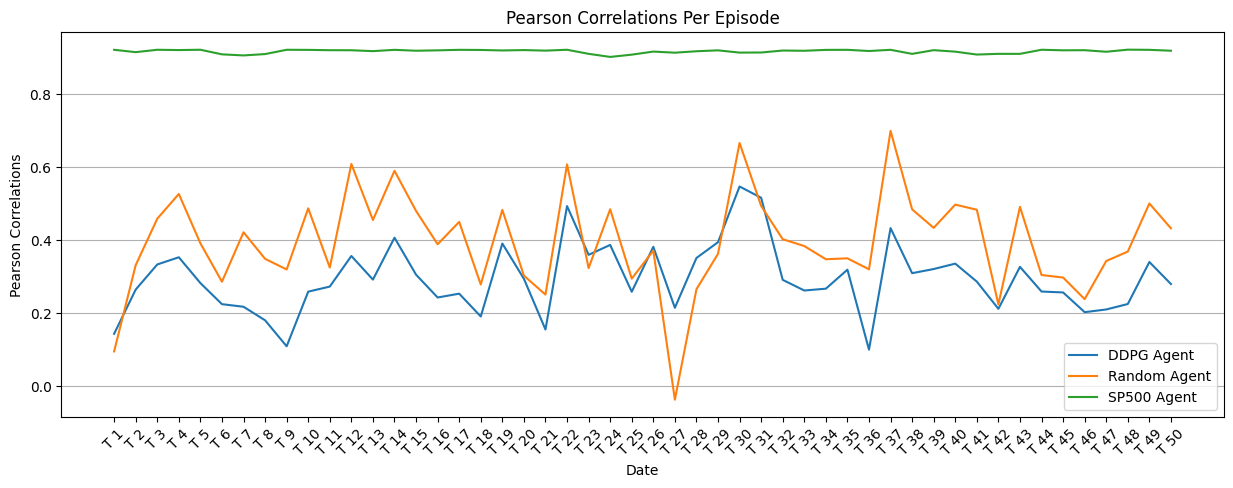

In [14]:
# Output 8 - Pearson Correlation
plotPearsonCorrelationMultiAgents(metrics_resume_avg)

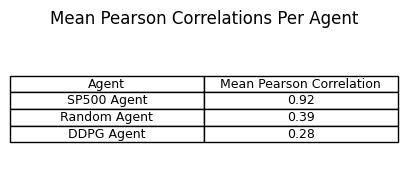

In [15]:
#T1
# Output 8.2 - Pearson Correlation Table
plotTableMeanPearsonCorrelationMultiAgents(metrics_resume_testing_avg)